# Augmented M1 Model for NFL Field Goal Success

This notebook extends the baseline M1 mixed-effects logistic regression model for NFL field goal success by incorporating additional training data from PAT attempts and non-attempt scenarios. The goal is to improve predictive performance through data augmentation while maintaining robust cross-validation.

Key features:
- Data preparation from `fg_all.csv` with kicker mapping from play-by-play data
- Construction of PAT and non-attempt master datasets
- Cross-validated evaluation of augmentation variants (e.g., weighted PAT inclusion, predicted non-attempt weights)
- Comparison against baseline M1 performance
- Outputs include metrics, calibration plots, and diagnostics

Prerequisites: Run the baseline notebooks (01-04) to ensure required data and models are available.

In [1]:
# --- Parameters & Setup ---
PROJECT_ROOT <- normalizePath('G:/My files/Python/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model', winslash = '\\', mustWork = FALSE)
if (!dir.exists(PROJECT_ROOT)) {
  PROJECT_ROOT <- normalizePath("C:/Users/ekerv/Proton Drive/RPC1001 (1)/My files/Python/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model", winslash = '\\', mustWork = FALSE)
  if (!dir.exists(PROJECT_ROOT)) {
    stop("Project root directory does not exist. Please check the path.")
  }
}

reference_dir <- file.path(PROJECT_ROOT, 'Reference')
data_dir <- file.path(PROJECT_ROOT, 'data')
reports_dir <- file.path(PROJECT_ROOT, 'reports')
config_path <- file.path(PROJECT_ROOT, 'config', 'params.yaml')
models_dir <- file.path(PROJECT_ROOT, 'models')

if (!dir.exists(reports_dir)) {
  dir.create(reports_dir, recursive = TRUE, showWarnings = FALSE)
}

# subdir for xfg
reports_xfg_dir <- file.path(reports_dir, 'xfg_success')
if (!dir.exists(reports_xfg_dir)) dir.create(reports_xfg_dir, recursive = TRUE)

SEASONS <- 2015:2024


# Distance spline controls (manual knots like ref_modeling)
DIST_KNOTS <- c(28,38,48,58)
DIST_BOUNDS <- c(18,70)

set.seed(20240517)

# Imports — install if missing

dependencies <- c(
  'dplyr', 'tibble', 'tidyr', 'readr', 'stringr', 'purrr', 'ggplot2',
  'splines', 'splines2', 'glmmTMB', 'pROC', 'yaml', 'rlang', 'scales', 'glmnet',
  'minqa'
)

installed <- rownames(installed.packages())

for (pkg in dependencies) {
  if (!pkg %in% installed) {
    install.packages(pkg)
  }
  suppressPackageStartupMessages(library(pkg, character.only = TRUE))
}


In [2]:
# Restored utilities: splines, metrics, scoring, calibration by distance
# These are strict helpers with no hidden fallbacks.

get_team_for_join <- function(df) {
  team_cols <- c("posteam", "team")
  team_col <- team_cols[team_cols %in% names(df)][1]
  if (is.na(team_col)) stop("No team column found in df")
  toupper(df[[team_col]])
}

# Distance B-splines using splines2
build_distance_bs <- function(x, knots, bknots, degree = 3, intercept = FALSE) {
  stopifnot(!missing(x), !missing(knots), !missing(bknots))
  if (!requireNamespace("splines2", quietly = TRUE)) stop("Package 'splines2' required")
  bs <- splines2::bSpline(x, knots = knots, Boundary.knots = bknots, degree = degree, intercept = intercept)
  bs <- as.data.frame(bs)
  names(bs) <- paste0("dist_bs_", seq_len(ncol(bs)))
  bs
}

# Loss metrics
brier <- function(y, p) {
  stopifnot(length(y) == length(p))
  y <- as.numeric(y)
  p <- pmin(pmax(as.numeric(p), 0), 1)
  mean((y - p)^2, na.rm = TRUE)
}

logloss <- function(y, p, eps = 1e-15) {
  stopifnot(length(y) == length(p))
  y <- as.numeric(y)
  p <- pmin(pmax(as.numeric(p), eps), 1 - eps)
  -mean(y * log(p) + (1 - y) * log(1 - p), na.rm = TRUE)
}

auc <- function(y, p) {
  stopifnot(length(y) == length(p))
  y <- as.numeric(y)
  p <- as.numeric(p)
  
  # Filter out NA/NaN/Inf from predictions or outcomes
  keep <- is.finite(p) & is.finite(y)
  if (sum(keep) == 0) return(NA_real_)
  yk <- y[keep]
  pk <- p[keep]
  
  if (length(unique(yk)) < 2) return(NA_real_)
  as.numeric(pROC::auc(yk, pk, quiet = TRUE))
}

# Generic probability scoring for GLM/GLMM models
score_probs <- function(model, data) {
  pr <- stats::predict(model, newdata = data, type = "response")
  as.numeric(pmin(pmax(pr, 0), 1))
}

# Build aggregated calibration table by distance for one probability column
make_calib_by_dist <- function(df, p_col, dist_col = 'kick_distance', y_col = 'kick_made', breaks = seq(15,70,5), right = FALSE, include.lowest = TRUE) {
  stopifnot(is.data.frame(df), p_col %in% names(df), dist_col %in% names(df), y_col %in% names(df))
  df %>%
    dplyr::mutate(
      dist_bin = cut(.data[[dist_col]], breaks = breaks, right = right, include.lowest = include.lowest)
    ) %>%
    dplyr::group_by(dist_bin) %>%
    dplyr::summarise(
      n = dplyr::n(),
      obs = mean(.data[[y_col]], na.rm = TRUE),
      est = mean(.data[[p_col]], na.rm = TRUE),
      .groups = 'drop'
    ) %>%
    dplyr::arrange(dist_bin)
}

# Calibration slope for three models (returns tidy table)
cal_slope_three <- function(df, prob_cols_named, treatment_label = NA_character_) {
  stopifnot(is.data.frame(df))
  out <- lapply(names(prob_cols_named), function(nm) {
    col <- prob_cols_named[[nm]]
    stopifnot(col %in% names(df))
    p <- pmin(pmax(df[[col]], 1e-6), 1 - 1e-6)
    lp <- qlogis(p)
    # enforce binary response; fallback to OLS if not strictly {0,1}
    y_raw <- df$kick_made
    y_bin <- as.integer(round(as.numeric(y_raw)))
    if (any(!is.finite(y_bin))) y_bin[!is.finite(y_bin)] <- NA_integer_
    if (all(y_bin %in% c(0L, 1L) | is.na(y_bin))) {
      fit <- suppressWarnings(stats::glm(y_bin ~ lp, family = stats::binomial()))
      co <- summary(fit)$coefficients
      slope <- unname(co[2, 1])
      se <- unname(co[2, 2])
    } else {
      # Non-binary outcomes detected; use linear model for a calibrated slope proxy
      y_num <- as.numeric(y_raw)
      fit <- stats::lm(y_num ~ lp)
      co <- summary(fit)$coefficients
      slope <- unname(co[2, 1])
      se <- unname(co[2, 2])
    }
    tibble::tibble(model = nm, slope = slope, se = se, treatment = treatment_label)
  })
  dplyr::bind_rows(out)
}

# Helper: safe prediction
predict_safe <- function(fit, newdata) {
  if (is.null(fit)) return(rep(NA_real_, nrow(newdata)))
  
  # Handle glmnet objects
  if (inherits(fit, "cv.glmnet")) {
    # We need the formula to create the model matrix correctly.
    if (!exists("m1_formula")) stop("m1_formula not found for glmnet prediction.")
    
    # Ensure newdata has all necessary columns, imputing 0 for any missing predictors
    required_predictors <- all.vars(lme4::nobars(m1_formula))
    required_predictors <- setdiff(required_predictors, "kick_made") # Exclude outcome
    
    for (col in required_predictors) {
        if (!col %in% names(newdata) && !grepl(":", col)) {
            newdata[[col]] <- 0
        }
    }
    
    # Create the model matrix from the test data
    test_x <- tryCatch(
      model.matrix(m1_formula, data = newdata)[, -1, drop = FALSE], # Drop intercept
      error = function(e) NULL
    )
    if (is.null(test_x)) return(rep(NA_real_, nrow(newdata)))
    
    # Align columns with the fitted model to handle potential discrepancies
    fit_coefs <- rownames(coef(fit, s = "lambda.min"))[-1] # Get predictor names from fit
    final_test_x <- matrix(0, nrow = nrow(test_x), ncol = length(fit_coefs), dimnames = list(NULL, fit_coefs))
    
    common_cols <- intersect(colnames(test_x), fit_coefs)
    if (length(common_cols) > 0) {
      final_test_x[, common_cols] <- test_x[, common_cols]
    }
    
    return(as.numeric(predict(fit, newx = final_test_x, s = "lambda.min", type = "response")))
  }
  
  # Handle glmmTMB/glm objects
  p_resp <- tryCatch(as.numeric(stats::predict(fit, newdata = newdata, type = "response", allow.new.levels = TRUE)),
                     error = function(e) NULL)
  if (!is.null(p_resp)) return(pmin(pmax(p_resp, 0), 1))
  
  p_link <- tryCatch(as.numeric(stats::predict(fit, newdata = newdata, type = "link", allow.new.levels = TRUE)),
                     error = function(e) NULL)
  if (!is.null(p_link)) return(plogis(p_link)) # Assuming logit link
  
  rep(NA_real_, nrow(newdata))
}

# Helper: Pool sparse random effect levels
pool_sparse_levels <- function(train_df, test_df, id_col = "kicker_player_id", min_n = 5L, repl = "REPL", keep_cols = NULL) {
  stopifnot(id_col %in% names(train_df), id_col %in% names(test_df))
  
  # Preserve original data to carry over all columns
  train_out <- train_df
  test_out <- test_df
  
  # Determine levels to pool based on training data counts
  tab <- table(train_out[[id_col]])
  keep_levels <- names(tab)[tab >= min_n]
  
  # Apply pooling to both train and test data
  train_out[[id_col]] <- ifelse(train_out[[id_col]] %in% keep_levels, as.character(train_out[[id_col]]), repl)
  test_out[[id_col]]  <- ifelse(test_out[[id_col]] %in% keep_levels,  as.character(test_out[[id_col]]),  repl)
  
  # Ensure factor levels are consistent
  all_levels <- unique(c(train_out[[id_col]], test_out[[id_col]]))
  train_out[[id_col]] <- factor(train_out[[id_col]], levels = all_levels)
  test_out[[id_col]]  <- factor(test_out[[id_col]], levels = all_levels)
  
  list(train = train_out, test = test_out)
}



In [3]:
# Build fg_all feature space, validate, and prebuild PAT/NON masters for modelling

# Load fg_all
fg_all <- readr::read_csv(file.path(data_dir, "fg_all.csv"), show_col_types = FALSE)

#Filter for SEASONS
fg_all <- fg_all %>% dplyr::filter(.data$season %in% SEASONS)
fg_all <- fg_all %>% dplyr::filter(play_type_original %in% c('field_goal','extra_point','pass','run','punt'))

#create kick_made column
fg_all <- fg_all %>% dplyr::mutate(
    kick_made = dplyr::case_when(
        .data$kick_result == "made" ~ 1,
        .data$kick_result == "missed" ~ 0,
        .data$kick_result == "blocked" ~ 0,
        TRUE ~ 0
    )
)

# Basic sanity on flags and outcomes
fg_all <- fg_all %>% dplyr::mutate(
  is_pat = as.integer(.data$is_pat),
  attempted = as.integer(.data$attempted),
  kick_distance = as.numeric(.data$kick_distance)
)

# Check NAs in kicker_player_id and kicker_player_name
#Replace "NA" with actual NA
fg_all$kicker_player_id <- ifelse(fg_all$kicker_player_id == "NA", NA, fg_all$kicker_player_id)
fg_all$kicker_player_name <- ifelse(fg_all$kicker_player_name == "NA", NA, fg_all$kicker_player_name)
fg_all$kick_result <- ifelse(fg_all$kick_result == "NA", NA, fg_all$kick_result)   

# Ensure kick_distance is within modelable range
fg_all <- fg_all %>% dplyr::filter(.data$kick_distance >= 18 & .data$kick_distance <= 70)

#Remove blocks keep NA kick_result
fg_all <- fg_all %>% dplyr::filter(.data$kick_result != 'blocked' | is.na(.data$kick_result))

fg_all <- fg_all %>% mutate(game_id = as.character(game_id))
fg_all$team_for_join <- get_team_for_join(fg_all)

na_id_before   <- sum(is.na(fg_all$kicker_player_id))
na_name_before <- sum(is.na(fg_all$kicker_player_name))

describe_fg_all <- fg_all %>%
  summarise(
    total_rows = n(),
    total_attempted = sum(attempted, na.rm = TRUE),
    total_made = sum(kick_made, na.rm = TRUE),
    pct_made = mean(kick_made, na.rm = TRUE),
    na_kicker_id = sum(is.na(kicker_player_id)),
    na_kicker_name = sum(is.na(kicker_player_name))
  )

describe_fg_all

total_rows,total_attempted,total_made,pct_made,na_kicker_id,na_kicker_name
<int>,<int>,<dbl>,<dbl>,<int>,<int>
33052,23071,21001,0.6353927,9981,9981


In [4]:
# --- Data Loading and Preparation ---

kicker_by_game_path <- file.path(data_dir, 'kicker_by_game.csv')
oof_path <- file.path(reports_dir, 'attempt_pi', 'attempt_pi_oof_predictions_final.csv')
kicker_by_game <- readr::read_csv(kicker_by_game_path, col_types = readr::cols())
oof_preds <- readr::read_csv(oof_path, col_types = readr::cols())

# Enforce consistent types for join keys before any operations
fg_all <- fg_all %>% dplyr::mutate(game_id = as.character(game_id), play_id = as.character(play_id), season = as.integer(season))
kicker_by_game <- kicker_by_game %>% dplyr::mutate(game_id = as.character(game_id), team = as.character(team))
oof_preds <- oof_preds %>% dplyr::mutate(game_id = as.character(game_id), play_id = as.character(play_id), season = as.integer(season))

cat("Enforced consistent data types for join key columns (game_id, play_id, season, team).\n")

# 2. Basic cleaning and feature creation for fg_all
fg_all <- fg_all %>%
  dplyr::filter(season %in% SEASONS, 
                play_type_original %in% c('field_goal', 'extra_point', 'pass', 'run', 'punt'),
                kick_distance >= 18 & kick_distance <= 70,
                kick_result != 'blocked' | is.na(kick_result)) %>%
  dplyr::mutate(
    kick_made = dplyr::case_when(kick_result == "made" ~ 1, kick_result %in% c("missed", "blocked") ~ 0, TRUE ~ 0),
    is_pat = as.integer(is_pat),
    attempted = as.integer(attempted),
    game_id = as.character(game_id),
    play_id = as.character(play_id),
    kicker_player_id = ifelse(kicker_player_id == "NA", NA, kicker_player_id),
    team_for_join = toupper(posteam)
  )

# 3. Impute missing kicker IDs using kicker_by_game
fg_all <- fg_all %>%
  dplyr::left_join(kicker_by_game %>% dplyr::select(game_id, team, kg_kicker_player_id = kicker_player_id), 
                   by = c("game_id" = "game_id", "team_for_join" = "team")) %>%
  dplyr::mutate(kicker_player_id = dplyr::coalesce(kicker_player_id, kg_kicker_player_id)) %>%
  dplyr::select(-kg_kicker_player_id)

# 4. Join OOF predictions for non-attempts
fg_all <- fg_all %>%
  dplyr::left_join(oof_preds %>% dplyr::select(season, game_id, play_id, p_hat_attempt_clipped), 
                   by = c("season", "game_id", "play_id"))

Enforced consistent data types for join key columns (game_id, play_id, season, team).


In [ ]:
# PBP Kicker Data Loading and By Game
pbp_paths <- c(
  "G:/Python/Data/NFL/pbp.rds",
  "g:/Python/Data/NFL/pbp.rds",
  "G:\\Python\\Data\\NFL\\pbp.rds",
  "g:\\Python\\Data\\NFL\\pbp.rds"
)
pbp_path <- pbp_paths[file.exists(pbp_paths)][1]
if (is.na(pbp_path) || length(pbp_path) == 0) {
  stop("pbp.rds not found in expected locations. Please adjust pbp_paths or place the file accordingly.")
}

pbp <- readRDS(pbp_path)

#Filter for only SEASONS
pbp <- pbp %>% dplyr::filter(.data$season %in% SEASONS)

# Detect columns robustly
has_col <- function(df, nm) nm %in% names(df)

# Kick attempt flags
fg_flag <- if (has_col(pbp, "field_goal_attempt")) pbp$field_goal_attempt == 1 else !is.na(pbp$field_goal_result)
xp_flag <- if (has_col(pbp, "extra_point_attempt")) pbp$extra_point_attempt == 1 else !is.na(pbp$extra_point_result)

# Kicker id and name columns in pbp
kid_col <- c("kicker_player_id")
kid_col <- kid_col[kid_col %in% names(pbp)][1]
if (is.na(kid_col)) stop("Could not find kicker id column in pbp")

kname_col <- c("kicker_player_name")
kname_col <- kname_col[kname_col %in% names(pbp)][1]
if (is.na(kname_col)) {
  # Fallback to NA name if none present
  pbp$kicker_player_name_tmp <- NA_character_
  kname_col <- "kicker_player_name_tmp"
}

# Team column in pbp (kicking team == posteam on FG/PAT plays)
team_col_pbp <- if (has_col(pbp, "posteam")) "posteam" else NA_character_
if (is.na(team_col_pbp)) stop("Could not find team column in pbp (expected posteam)")

# Time remaining and play id/order for recency selection
time_cols <- c("game_seconds_remaining")
use_time_col <- time_cols[time_cols %in% names(pbp)][1]

# Base schedule (home/away pairs) for all games in pbp
sched <- pbp %>%
  dplyr::distinct(season, week, game_id, home_team, away_team) %>%
  tidyr::pivot_longer(c(home_team, away_team), names_to = "ha", values_to = "team") %>%
  dplyr::arrange(season, week, game_id) %>%
  dplyr::select(season, week, game_id, team) %>%
  dplyr::mutate(team = toupper(as.character(team)), game_id = as.character(game_id))

# Kicks by team/game with kicker id+name and recency features
pbp_kicks <- pbp %>%
  dplyr::filter((fg_flag | xp_flag) & !is.na(.data[[kid_col]]) & !is.na(.data[[team_col_pbp]])) %>%
  dplyr::transmute(
    season = .data$season,
    week = .data$week,
    game_id = as.character(.data$game_id),
    team = toupper(as.character(.data[[team_col_pbp]])),
    kicker_player_id = as.character(.data[[kid_col]]),
    kicker_player_name = as.character(.data[[kname_col]]),
    t_rem = if (!is.na(use_time_col)) suppressWarnings(as.numeric(.data[[use_time_col]])) else NA_real_,
    play_ord = if (has_col(pbp, "play_id")) suppressWarnings(as.numeric(.data$play_id)) else dplyr::row_number()
  )

# For each kicker within game+team, compute the last (latest) kick timing
kicker_last <- pbp_kicks %>%
  dplyr::group_by(game_id, team, kicker_player_id, kicker_player_name) %>%
  dplyr::summarise(
    last_time_remaining = suppressWarnings(min(t_rem, na.rm = TRUE)),
    last_play_ord = suppressWarnings(max(play_ord, na.rm = TRUE)),
    n = dplyr::n(),
    .groups = "drop"
  ) %>%
  dplyr::mutate(last_time_remaining = ifelse(is.finite(last_time_remaining), last_time_remaining, NA_real_))

# Choose the kicker with least time remaining (latest into the game); break ties by last_play_ord then by number of kicks
kicker_game_top <- kicker_last %>%
  dplyr::group_by(game_id, team) %>%
  dplyr::arrange(last_time_remaining, dplyr::desc(last_play_ord), dplyr::desc(n), .by_group = TRUE) %>%
  dplyr::slice(1) %>%
  dplyr::ungroup()

# Merge onto full game-team schedule, then LOCF fill by team across chronological order
kicker_by_game <- sched %>%
  dplyr::left_join(kicker_game_top %>% dplyr::select(game_id, team, kicker_player_id, kicker_player_name), by = c("game_id", "team")) %>%
  dplyr::group_by(team) %>%
  dplyr::arrange(season, week, game_id, .by_group = TRUE) %>%
  tidyr::fill(kicker_player_id, kicker_player_name, .direction = "downup") %>%
  dplyr::ungroup()

#Show summary of top 10 kickers by number of games assigned
top_kickers <- kicker_by_game %>%
  dplyr::group_by(kicker_player_id, kicker_player_name) %>%
  dplyr::summarise(num_games = dplyr::n(), .groups = 'drop') %>%
  dplyr::arrange(dplyr::desc(num_games)) %>%
  dplyr::slice_head(n = 10)

top_kickers

#save kicker_by_game
readr::write_csv(kicker_by_game, file.path(data_dir, "kicker_by_game.csv"))

In [5]:
# Prepare to merge into fg_all
if (!exists("fg_all")) stop("fg_all not found in environment; run the data prep cell that creates fg_all first.")

# Primary join by game_id + team
fg_all <- fg_all %>%
  dplyr::left_join(kicker_by_game %>% dplyr::select(game_id, team, kg_kicker_player_id = kicker_player_id, kg_kicker_player_name = kicker_player_name),
                   by = c("game_id" = "game_id", "team_for_join" = "team")) %>%
  dplyr::mutate(
    kicker_player_id = dplyr::coalesce(kicker_player_id, kg_kicker_player_id),
    kicker_player_name = dplyr::coalesce(kicker_player_name, kg_kicker_player_name)
  ) %>%
  dplyr::select(-kg_kicker_player_id, -kg_kicker_player_name)

# Fallback: for rows still missing and where the game has only one kicker entry (rare), join by game_id only
if (anyNA(fg_all$kicker_player_id) || anyNA(fg_all$kicker_player_name)) {
  one_kicker_games <- kicker_by_game %>% dplyr::group_by(game_id) %>% dplyr::filter(dplyr::n() == 1) %>% dplyr::ungroup() %>% dplyr::select(game_id, fallback_kicker_player_id = kicker_player_id, fallback_kicker_player_name = kicker_player_name)
  fg_all <- fg_all %>%
    dplyr::left_join(one_kicker_games, by = c("game_id" = "game_id")) %>%
    dplyr::mutate(
      kicker_player_id = dplyr::coalesce(kicker_player_id, fallback_kicker_player_id),
      kicker_player_name = dplyr::coalesce(kicker_player_name, fallback_kicker_player_name)
    ) %>%
    dplyr::select(-fallback_kicker_player_id, -fallback_kicker_player_name)
}

na_id_after   <- sum(is.na(fg_all$kicker_player_id))
na_name_after <- sum(is.na(fg_all$kicker_player_name))

cat(sprintf("Filled kicker_player_id: %d newly filled; %d remaining NA.\n", na_id_before - na_id_after, na_id_after))
cat(sprintf("Filled kicker_player_name: %d newly filled; %d remaining NA.\n", na_name_before - na_name_after, na_name_after))

# Sanity checks: ensure no NA in fg_all for kicker_player_id and name
if (na_id_after > 0 || na_name_after > 0) {
  warning(sprintf("After merging, fg_all still has NA kicker fields: id=%d, name=%d. Verify team columns for those rows (e.g., missing team/game mapping).", na_id_after, na_name_after))
} else {
  cat("fg_all kicker_player_id and kicker_player_name have no missing values.\n")
}

# Create kicker age and experience table from attempted kicks
kicker_info <- fg_all %>%
  dplyr::filter(.data$attempted == 1) %>%
  dplyr::select(season, kicker_player_id, kicker_age, kicker_experience) %>%
  dplyr::distinct(kicker_player_id, season, .keep_all = TRUE)

# Merge kicker_info back to fg_all on kicker_player_id and season
fg_all <- fg_all %>%
    dplyr::left_join(kicker_info, by = c("kicker_player_id", "season")) %>%
    dplyr::mutate(
        kicker_age = dplyr::coalesce(kicker_age.x, kicker_age.y),
        kicker_experience = dplyr::coalesce(kicker_experience.x, kicker_experience.y)
    ) %>%
    dplyr::select(-kicker_age.x, -kicker_age.y, -kicker_experience.x, -kicker_experience.y)

# Standardize kicker_age and kicker_experience to z-scores
fg_all <- fg_all %>%
  dplyr::mutate(
    kicker_age_z = as.numeric(scale(kicker_age)),
    kicker_experience_z = as.numeric(scale(kicker_experience))
  )

#show NA counts for age and experience z-scores
cat(sprintf("NA in kicker_age_z: %d\n", sum(is.na(fg_all$kicker_age_z))))
cat(sprintf("NA in kicker_experience_z: %d\n", sum(is.na(fg_all$kicker_experience_z))))
colnames(fg_all)

Filled kicker_player_id: 9981 newly filled; 0 remaining NA.
Filled kicker_player_name: 9981 newly filled; 0 remaining NA.
fg_all kicker_player_id and kicker_player_name have no missing values.
NA in kicker_age_z: 0
NA in kicker_experience_z: 0


[1] "game_id"                    "play_id"                   
 [3] "old_game_id"                "season"                    
 [5] "week"                       "season_type"               
 [7] "playoffs"                   "qtr"                       
 [9] "game_date"                  "home_team"                 
[11] "away_team"                  "posteam"                   
[13] "defteam"                    "game_seconds_remaining"    
[15] "quarter_seconds_remaining"  "score_differential"        
[17] "yardline_100"               "ydstogo"                   
[19] "wp"                         "home_wp"                   
[21] "epa"                        "posteam_timeouts_remaining"
[23] "defteam_timeouts_remaining" "goal_to_go"                
[25] "is_ot"                      "roof"                      
[27] "surface"                    "temp"                      
[29] "wind"                       "weather"                   
[31] "stadium_id"                 "stadium"                   
[33] "location"                   "kick_distance"             
[35] "kicker_player_id"           "kicker_player_name"        
[37] "field_goal_result"          "extra_point_result"        
[39] "kick_result"                "is_pat"                    
[41] "attempted"                  "play_type_original"        
[43] "down"                       "prev_play_type"            
[45] "prev_desc"                  "prev_timeout"              
[47] "prev_timeout_team"          "prev_penalty"              
[49] "prev_incomplete"            "prev_out_bounds"           
[51] "prev_end_quarter"           "prev_two_min_warning"      
[53] "delta_secs"                 "l2m"                       
[55] "clock_running"              "iced"                      
[57] "birth_date"                 "rookie_season"             
[59] "roof_std"                   "indoors"                   
[61] "surface_std"                "is_turf"                   
[63] "high_altitude"              "weather_first"             
[65] "weather_clean"              "humidity"                  
[67] "is_snow_sleet"              "is_rain_showers"           
[69] "is_cloudy"                  "is_hazy_fog"               
[71] "wp_make_hat"                "wp_miss_hat"               
[73] "leverage"                   "wp_make_hat_rules"         
[75] "wp_miss_hat_rules"          "leverage_rules"            
[77] "pred_hat_post"              "wind_z"                    
[79] "temp_z"                     "humidity_z"                
[81] "kicker_age_z"               "kicker_experience_z"       
[83] "season_z"                   "kick_made"                 
[85] "eoh_urgency"                "eog_urgency"               
[87] "go_ahead"                   "to_tie"                    
[89] "one_score"                  "leverage_z"                
[91] "team_for_join"              "p_hat_attempt_clipped"     
[93] "kicker_age"                 "kicker_experience"

In [6]:
# --- Load the canonical M1 model and extract its formula ---
# This ensures the exact same formula is used for predictions and experiments.

m1_model_path <- file.path(models_dir, "m1", "m1_fg_B_logit.rds")
if (!file.exists(m1_model_path)) {
  stop("Canonical M1 model not found at: ", m1_model_path, 
       ". Please run 04_xfg_success_ipw.ipynb to generate it.")
}
m1_saved_model <- readRDS(m1_model_path)
m1_formula <- formula(m1_saved_model)

cat("Successfully loaded M1 model and extracted formula:\n")
print(m1_formula)

# --- Ensure all required features, including splines, exist on fg_all ---
# Build distance spline basis for the entire fg_all dataset first.
stopifnot(exists("build_distance_bs"), exists("DIST_KNOTS"), exists("DIST_BOUNDS"))
if (!any(grepl("^dist_bs_", names(fg_all)))) {
  dist_mat_fg_all <- build_distance_bs(fg_all$kick_distance, knots = DIST_KNOTS, bknots = DIST_BOUNDS)
  fg_all <- dplyr::bind_cols(fg_all, dist_mat_fg_all)
  cat("\nBuilt and added distance spline columns to fg_all.\n")
} else {
  cat("\nDistance spline columns already exist in fg_all. Skipping creation.\n")
}

# Helpers to extract variable names from the formula
fixed_vars <- function(form) { setdiff(all.vars(lme4::nobars(form)), c("kick_made")) }
random_group_vars <- function(form) {
  fb <- lme4::findbars(form)
  if (length(fb) == 0) return(character())
  unique(unlist(lapply(fb, function(tt) setdiff(all.vars(tt), c("kick_made")))))
}

# Determine all variables needed for modeling based on the potentially modified formula
fv_names <- fixed_vars(m1_formula)
rg_names <- random_group_vars(m1_formula)
sel_vars <- unique(c("kick_made", fv_names, rg_names, "season")) # Ensure season is included for RE

# Snippet to enforce numeric types and impute NAs for model stability
for (col in sel_vars) {
  if (col %in% c("stadium_id", "kicker_player_id")) {
    fg_all[[col]] <- as.character(fg_all[[col]])
  } else if (is.numeric(fg_all[[col]])) {
    # For numeric columns, just impute NA with 0
    if (any(is.na(fg_all[[col]]))) {
      fg_all[[col]][is.na(fg_all[[col]])] <- 0
    }
  } else {
    # For non-numeric columns that should be numeric, convert and impute
    original <- fg_all[[col]]
    converted <- suppressWarnings(as.numeric(original))
    if (any(is.na(converted) & !is.na(original))) {
      warning(sprintf("Column '%s' has non-numeric values that were converted to NA.", col))
    }
    converted[is.na(converted)] <- 0
    fg_all[[col]] <- converted
  }
}
cat("Verified and cleaned model variable types in fg_all.\n")


# --- Prebuild PAT, NON, and FG master frames ---
must_have <- unique(c(sel_vars, "game_id"))
PAT_master <- fg_all %>%
  dplyr::filter(.data$attempted == 1L, .data$is_pat == 1L)
NON_master <- fg_all %>%
  dplyr::filter(.data$attempted == 0L) %>%
  dplyr::mutate(kick_made = 0L)
FG_master <- fg_all %>%
  dplyr::filter(.data$attempted == 1L, .data$is_pat == 0L)

# Add placeholder obs_weight column to each master frame
PAT_master$obs_weight <- NA_real_
NON_master$obs_weight <- NA_real_
FG_master$obs_weight <- NA_real_

# Final check on master frame sizes
cat(sprintf("\nPAT_master rows: %d\n", nrow(PAT_master)))
cat(sprintf("NON_master rows: %d\n", nrow(NON_master)))
cat(sprintf("FG_master rows: %d\n", nrow(FG_master)))

# More robust NA check for required columns in PAT_master and NON_master
# All columns other than stadium_id and kicker_player_id should be numeric.
# This checks types, counts NAs, and flags issues.

na_summary <- data.frame(
  column = character(),
  is_numeric = logical(),
  na_pat = integer(),
  na_non = integer(),
  non_numeric_pat = integer(),
  non_numeric_non = integer(),
  stringsAsFactors = FALSE
)

for (col in sel_vars) {
  pat_col <- PAT_master[[col]]
  non_col <- NON_master[[col]]
  
  if (col %in% c("stadium_id", "kicker_player_id")) {
    # These can be character/factor; just count NAs
    is_num <- FALSE
    na_pat <- sum(is.na(pat_col))
    na_non <- sum(is.na(non_col))
    non_num_pat <- NA_integer_
    non_num_non <- NA_integer_
  } else {
    # Should be numeric; check and count issues
    is_num <- is.numeric(pat_col) && is.numeric(non_col)
    if (!is_num) {
      warning(sprintf("Column '%s' is not numeric in PAT_master or NON_master.", col))
    }
    na_pat <- sum(is.na(pat_col))
    na_non <- sum(is.na(non_col))
    # Count non-numeric values (for robustness, even if column is numeric)
    non_num_pat <- sum(!is.na(pat_col) & !is.numeric(pat_col))
    non_num_non <- sum(!is.na(non_col) & !is.numeric(non_col))
  }
  
  na_summary <- rbind(na_summary, data.frame(
    column = col,
    is_numeric = is_num,
    na_pat = na_pat,
    na_non = na_non,
    non_numeric_pat = non_num_pat,
    non_numeric_non = non_num_non
  ))
}

# Order by total NA count descending
na_summary <- na_summary[order(-(na_summary$na_pat + na_summary$na_non)), ]

na_summary

Successfully loaded M1 model and extracted formula:
kick_made ~ dist_bs_1 + dist_bs_2 + dist_bs_3 + dist_bs_4 + dist_bs_5 + 
    dist_bs_6 + dist_bs_7 + wind_z * temp_z + indoors + high_altitude + 
    is_rain_showers + is_snow_sleet + is_ot + iced + clock_running * 
    posteam_timeouts_remaining + kicker_age_z:kicker_experience_z + 
    (dist_bs_1):wind_z + (dist_bs_2):wind_z + (dist_bs_3):wind_z + 
    (dist_bs_4):wind_z + (dist_bs_5):wind_z + (dist_bs_6):wind_z + 
    (dist_bs_7):wind_z + (dist_bs_1):temp_z + (dist_bs_2):temp_z + 
    (dist_bs_3):temp_z + (dist_bs_4):temp_z + (dist_bs_5):temp_z + 
    (dist_bs_6):temp_z + (dist_bs_7):temp_z + (1 | stadium_id) + 
    (1 | season:kicker_player_id)
<environment: 0x0000021aeda24510>

Built and added distance spline columns to fg_all.
Verified and cleaned model variable types in fg_all.

PAT_master rows: 12639
NON_master rows: 9981
FG_master rows: 10432


,column,is_numeric,na_pat,na_non,non_numeric_pat,non_numeric_non
,<chr>,<lgl>,<int>,<int>,<int>,<int>
1,kick_made,TRUE,0,0,0,0
2,dist_bs_1,TRUE,0,0,0,0
3,dist_bs_2,TRUE,0,0,0,0
4,dist_bs_3,TRUE,0,0,0,0
5,dist_bs_4,TRUE,0,0,0,0
6,dist_bs_5,TRUE,0,0,0,0
7,dist_bs_6,TRUE,0,0,0,0
8,dist_bs_7,TRUE,0,0,0,0
9,wind_z,TRUE,0,0,0,0


In [ ]:
# Load baseline M1 model and predict xFG for NON_master rows
# These predictions will serve as weights for non-attempt variants

# Load the saved M1 model
m1_model_path <- file.path(models_dir, "m1", "m1_fg_B_logit.rds")
if (!file.exists(m1_model_path)) {
  stop("M1 model file not found at: ", m1_model_path)
}
m1_saved_model <- readRDS(m1_model_path)

# Predict expected FG success probabilities for NON_master
xfg_pred <- (m1_saved_model, NON_master)

# Add predictions as a new column to NON_master
NON_master <- NON_master %>%
  dplyr::mutate(xfg_pred = xfg_pred)


# Summary of predictions
cat(sprintf("NON_master predictions summary:\n"))
cat(sprintf("Rows: %d\n", nrow(NON_master)))
cat(sprintf("NA predictions: %d\n", sum(is.na(xfg_pred))))
cat(sprintf("Valid predictions: %d\n", sum(!is.na(xfg_pred))))
cat(sprintf("Mean xFG: %.3f\n", mean(xfg_pred, na.rm = TRUE)))
cat(sprintf("Median xFG: %.3f\n", median(xfg_pred, na.rm = TRUE)))
cat(sprintf("Min xFG: %.3f\n", min(xfg_pred, na.rm = TRUE)))
cat(sprintf("Max xFG: %.3f\n", max(xfg_pred, na.rm = TRUE)))

NON_master predictions summary:
Rows: 9981
NA predictions: 0
Valid predictions: 9981
Mean xFG: 0.531
Median xFG: 0.590
Min xFG: 0.000
Max xFG: 1.000


kick_distance,xfg_pred,p_hat_attempt_clipped,obs_weight,kick_made,dist_bs_1,dist_bs_2,dist_bs_3,dist_bs_4,dist_bs_5,⋯,is_ot,iced,clock_running,posteam_timeouts_remaining,kicker_age_z,kicker_experience_z,stadium_id,season,kicker_player_id,game_id
<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>
26,0.991,0.9511692,NA,0,0.416,0.49066667,0.085333333,0.000000000,0.0000000,⋯,0,0,1,1,-0.2031195,0.01574645,JAX00,2015,00-0026858,2015_01_CAR_JAX
65,0.095,0.0200000,NA,0,0.000,0.00000000,0.000000000,0.014796402,0.2083154,⋯,0,0,1,3,-0.2031195,0.01574645,JAX00,2015,00-0026858,2015_01_CAR_JAX
66,0.031,0.0200000,NA,0,0.000,0.00000000,0.000000000,0.007575758,0.1430211,⋯,0,0,0,3,-0.2031195,0.01574645,JAX00,2015,00-0026858,2015_01_CAR_JAX
20,1.000,0.7498406,NA,0,0.434,0.05266667,0.001333333,0.000000000,0.0000000,⋯,0,0,1,2,0.8213556,0.83022462,OAK00,2015,00-0023482,2015_01_CIN_OAK
61,0.467,0.0200000,NA,0,0.000,0.00000000,0.000000000,0.086292614,0.4785318,⋯,0,0,1,2,0.8213556,0.83022462,OAK00,2015,00-0023482,2015_01_CIN_OAK
70,0.000,0.0200000,NA,0,0.000,0.00000000,0.000000000,0.000000000,0.0000000,⋯,0,0,0,3,1.6243375,1.84832234,OAK00,2015,00-0019646,2015_01_CIN_OAK


[1] 0.02
[1] 0.98
Total non-attempt rows with non-missing p_hat_attempt_clipped: 9981
# A tibble: 5 × 3
  threshold_label count pct_label
  <chr>           <int> <chr>    
1 5%               4476 44.8%    
2 10%              3726 37.3%    
3 25%              2616 26.2%    
4 50%              1608 16.1%    
5 75%               728 7.3%     
Data integrity check passed: All NON_master rows have kick_made == 0


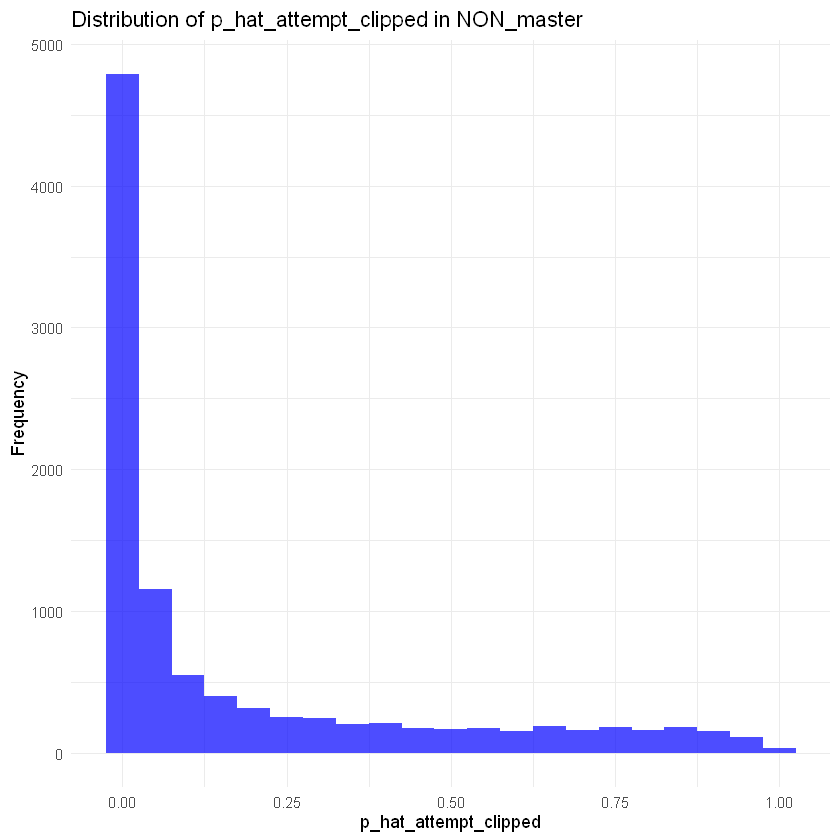

In [8]:
head(NON_master %>% 
    dplyr::select(dplyr::any_of(c(must_have, "xfg_pred", "kick_distance","p_hat_attempt_clipped","obs_weight"))) %>% 
    dplyr::select(kick_distance, xfg_pred, p_hat_attempt_clipped, obs_weight, dplyr::everything()) %>% 
    dplyr::mutate(xfg_pred = round(xfg_pred, 3)))

# Show distribution of p_hat_attempt_clipped for NON_master
ggplot2::ggplot(NON_master, aes(x = p_hat_attempt_clipped)) +
    ggplot2::geom_histogram(binwidth = 0.05, fill = "blue", alpha = 0.7) +
    ggplot2::labs(title = "Distribution of p_hat_attempt_clipped in NON_master", x = "p_hat_attempt_clipped", y = "Frequency") +
    ggplot2::theme_minimal()

print(min(NON_master$p_hat_attempt_clipped, na.rm = TRUE))
print(max(NON_master$p_hat_attempt_clipped, na.rm = TRUE))
# Percent of NON_master observations with p_hat_attempt_clipped above 25%, 50%, 75%
thresholds <- c(0.05, 0.1, 0.25, 0.50, 0.75)
total_obs <- sum(!is.na(NON_master$p_hat_attempt_clipped))

res_df <- tibble::tibble(threshold = thresholds) %>%
    dplyr::rowwise() %>%
    dplyr::mutate(
        count = sum(NON_master$p_hat_attempt_clipped > threshold, na.rm = TRUE),
        pct = if (total_obs > 0) count / total_obs else NA_real_
    ) %>%
    dplyr::ungroup() %>%
    dplyr::mutate(
        threshold_label = scales::percent(threshold),
        pct_label = scales::percent(pct, accuracy = 0.1)
    ) %>%
    dplyr::select(threshold_label, count, pct_label)

print(glue::glue("Total non-attempt rows with non-missing p_hat_attempt_clipped: {total_obs}"))
print(res_df)

#Verify kick_made is 0 for all NON_master rows
if (any(NON_master$kick_made != 0)) {
    stop("Data integrity check failed: Some NON_master rows have kick_made != 0")
} else {
    cat("Data integrity check passed: All NON_master rows have kick_made == 0\n")
}

In [18]:
# Create a single Train/Test split from FG_master based on a random sample of games
set.seed(202407) # Use a seed for reproducibility
TEST_RATIO <- 0.30

# Get unique game IDs from the field goal data
fg_game_ids <- unique(FG_master$game_id)
test_game_ids <- sample(fg_game_ids, size = floor(TEST_RATIO * length(fg_game_ids)), replace = FALSE)
train_game_ids <- setdiff(fg_game_ids, test_game_ids)

# Create the train/test sets for FGs
train_fg <- FG_master %>% dplyr::filter(game_id %in% train_game_ids)
test_fg  <- FG_master %>% dplyr::filter(game_id %in% test_game_ids)

cat(sprintf("Total FG Games: %d\\n", length(fg_game_ids)))
cat(sprintf("Train Games: %d | Test Games: %d\\n", length(train_game_ids), length(test_game_ids)))
cat(sprintf("Train FG rows: %d | Test FG rows: %d\\n", nrow(train_fg), nrow(test_fg)))

# Save train_fg and test_fg to CSV files in data/augmented
augmented_dir <- file.path(data_dir, 'augmented')
if (!dir.exists(augmented_dir)) {
  dir.create(augmented_dir, recursive = TRUE, showWarnings = FALSE)
}
readr::write_csv(train_fg, file.path(augmented_dir, "train_fg.csv"))
readr::write_csv(test_fg, file.path(augmented_dir, "test_fg.csv"))
readr::write_csv(test_game_ids %>% tibble::enframe(name = "row_id", value = "game_id"), file.path(augmented_dir, "test_fg_game_ids.csv"))
cat(sprintf("Saved train_fg to %s\\n", file.path(augmented_dir, "train_fg.csv")))
cat(sprintf("Saved test_fg to %s\\n", file.path(augmented_dir, "test_fg.csv")))

Total FG Games: 2700\nTrain Games: 1890 | Test Games: 810\nTrain FG rows: 7238 | Test FG rows: 3194\nSaved train_fg to G:\My files\Python\Sports Analytics Projects\Football\Kickers\NFL-Field-Goal-Kicker-Model/data/augmented/train_fg.csv\nSaved test_fg to G:\My files\Python\Sports Analytics Projects\Football\Kickers\NFL-Field-Goal-Kicker-Model/data/augmented/test_fg.csv\n

In [10]:
# --- Baseline Model (FG data only) ---
# This provides the benchmark to compare augmented models against.

# Load required metric functions if they are not in the global environment
stopifnot(exists("predict_safe"), exists("auc"), exists("brier"), exists("logloss"))

cat("Fitting baseline model (FG data only)...\\n")
# Using the m1_formula defined in a previous cell
ctrl <- glmmTMB::glmmTMBControl(optimizer = optim, optArgs = list(method = "BFGS"))
fit_base <- glmmTMB::glmmTMB(m1_formula, 
                            data = train_fg, 
                            family = binomial(link = "logit"), 
                            control = ctrl)
                            #weights = obs_weight

# Evaluate on the test set
p_base <- predict_safe(fit_base, test_fg)
baseline_metrics <- tibble::tibble(
  variant = "baseline_fg_only",
  auc = auc(test_fg$kick_made, p_base),
  brier = brier(test_fg$kick_made, p_base),
  logloss = logloss(test_fg$kick_made, p_base)
)

cat("Baseline Performance:\\n")
print(baseline_metrics)


Fitting baseline model (FG data only)...\n

Baseline Performance:\n# A tibble: 1 × 4
  variant            auc  brier logloss
  <chr>            <dbl>  <dbl>   <dbl>
1 baseline_fg_only 0.771 0.0978   0.323
